<a href="https://colab.research.google.com/github/karinaismayacantik8/JURNAL/blob/main/smotetomek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
from google.colab import files


# =========================================================
# UPLOAD FILE DARI KOMPUTER
# =========================================================
uploaded = files.upload()  # pilih file CSV dari folder kamu


# =========================================================
# LOAD DATASET
# =========================================================
# Ganti nama file sesuai file yang kamu upload
df = pd.read_csv("survey_lung_cancer.csv")


# =========================================================
# CEK DATA AWAL
# =========================================================
print("Ukuran dataset (baris, kolom):", df.shape)
print("\n5 data teratas:")
print(df.head())

print("\nInformasi dataset:")
print(df.info())


Kolom target: LUNG_CANCER
Distribusi kelas target:
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

[1] Informasi Umum Dataset
Jumlah baris dan kolom: (309, 16)
Nama kolom:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']

[2] Tipe Data Setiap Kolom
GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

[3] Statistik Deskri

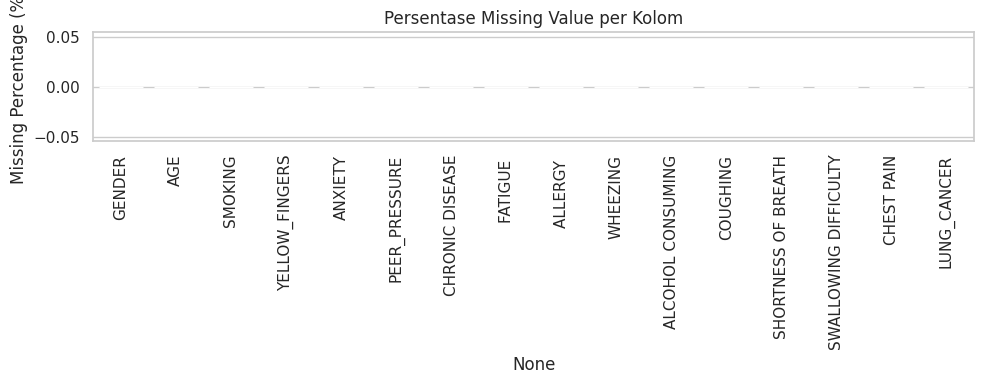


[5] Distribusi Kelas Target (Jumlah)
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

Distribusi Kelas Target (Persentase)
LUNG_CANCER
YES    87.378641
NO     12.621359
Name: proportion, dtype: float64


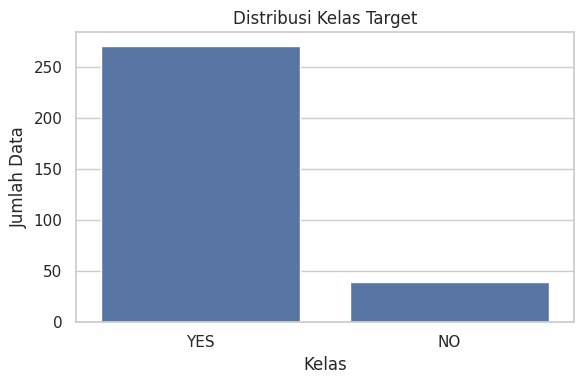

Jumlah data duplikat: 33

[BARIS DUPLIKAT SAJA]


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
99,MALE,56,1,0,0,0,0,1,1,1,1,1,1,0,1,YES
100,MALE,58,1,0,0,0,0,0,1,1,1,1,0,0,0,YES
117,FEMALE,51,1,1,1,1,0,1,1,0,0,0,1,1,0,YES
199,FEMALE,55,1,0,0,1,1,1,1,1,1,0,0,1,1,YES
212,MALE,58,1,0,0,0,0,1,1,1,1,1,1,0,1,YES
223,MALE,63,1,1,1,0,1,1,1,1,0,0,1,0,0,YES
256,MALE,60,1,0,0,0,0,1,1,1,1,1,1,0,1,YES
275,MALE,64,1,1,1,1,1,0,0,0,1,0,0,1,1,YES
284,MALE,58,1,1,1,1,1,0,0,0,1,0,0,1,1,YES
285,FEMALE,58,1,1,1,1,0,1,0,0,0,1,1,1,0,YES



[DATA DUPLIKAT + PASANGAN ASLINYA]


,Row_Index,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,140,FEMALE,47,1,1,0,1,1,1,1,1,0,1,1,0,0,YES
1,297,FEMALE,47,1,1,0,1,1,1,1,1,0,1,1,0,0,YES
2,130,FEMALE,51,1,1,1,1,0,1,0,0,0,0,1,1,0,YES
3,287,FEMALE,51,1,1,1,1,0,1,0,0,0,0,1,1,0,YES
4,7,FEMALE,51,1,1,1,1,0,1,1,0,0,0,1,1,0,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,305,MALE,70,1,0,0,0,0,1,1,1,1,1,1,0,1,YES
62,134,MALE,71,1,1,1,0,1,0,1,1,1,1,0,1,1,YES
63,291,MALE,71,1,1,1,0,1,0,1,1,1,1,0,1,1,YES
64,133,MALE,76,1,0,0,0,0,1,1,1,1,1,1,0,1,YES



[DUPLIKAT BERDASARKAN KOLOM ['AGE', 'GENDER']]


,Row_Index,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,140,FEMALE,47,1,1,0,1,1,1,1,1,0,1,1,0,0,YES
1,297,FEMALE,47,1,1,0,1,1,1,1,1,0,1,1,0,0,YES
2,58,MALE,47,0,1,0,1,1,1,0,1,0,0,1,1,1,YES
3,156,MALE,47,1,1,0,0,1,0,0,0,0,0,0,0,1,NO
4,108,FEMALE,49,0,0,0,1,1,0,1,0,1,1,1,0,0,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,185,MALE,77,1,0,0,0,0,0,1,1,1,1,0,0,0,YES
291,234,MALE,77,0,1,0,1,0,1,1,1,1,1,0,0,0,YES
292,242,MALE,77,1,1,1,0,1,0,1,1,0,0,0,1,1,YES
293,83,FEMALE,81,0,0,0,1,1,0,1,0,1,1,1,0,0,YES


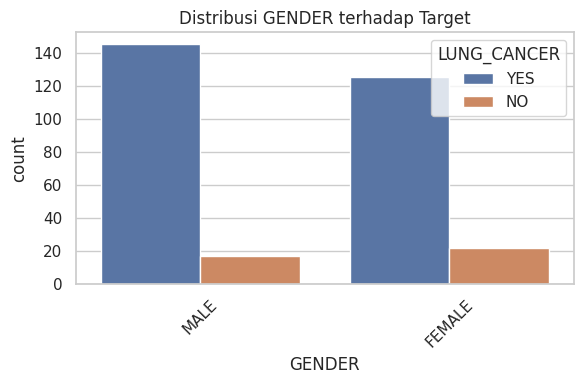

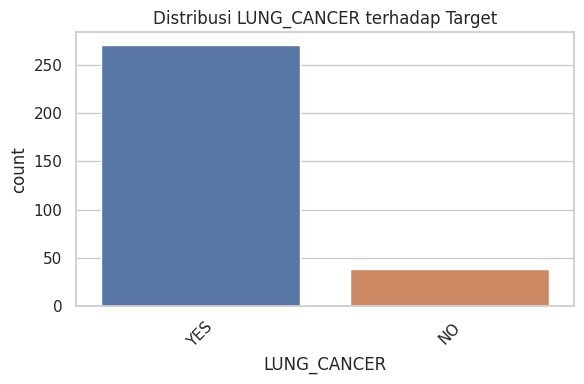

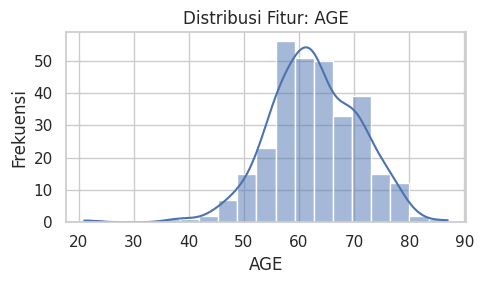

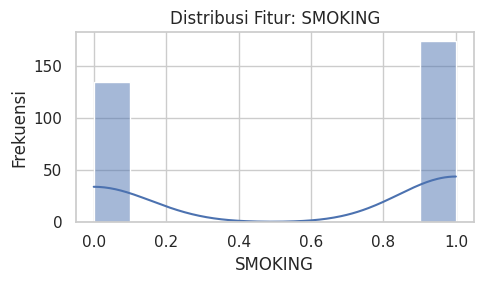

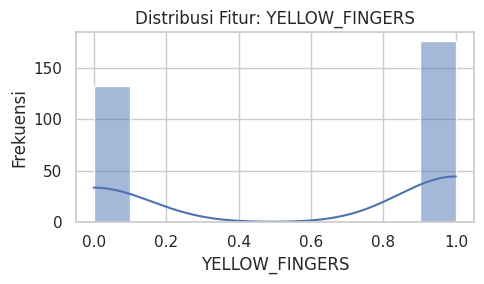

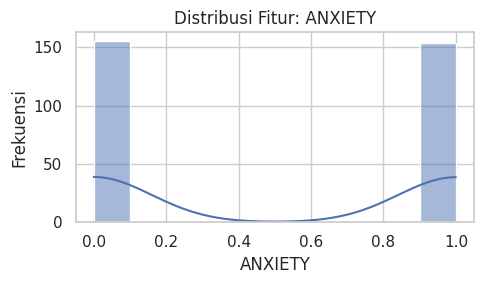

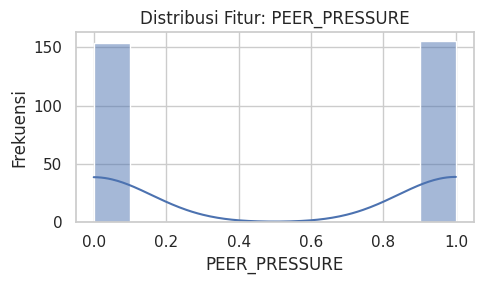

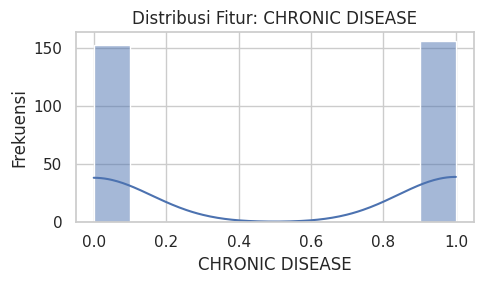

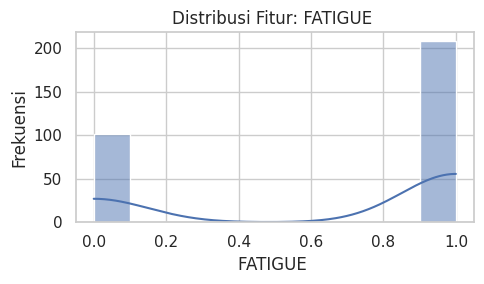

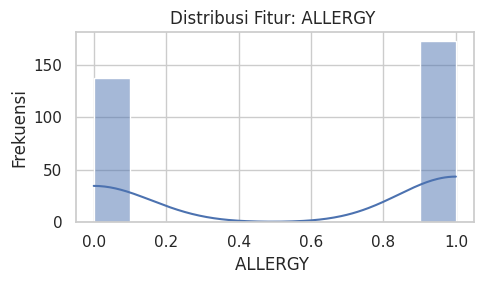

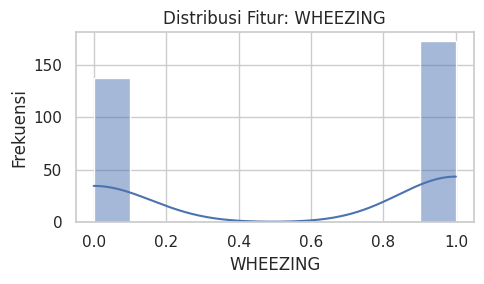

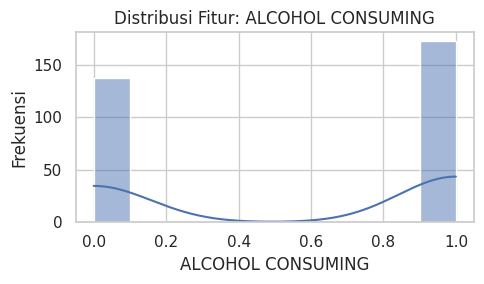

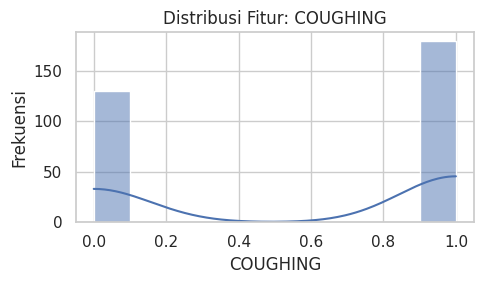

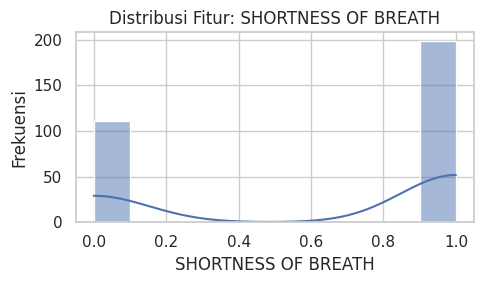

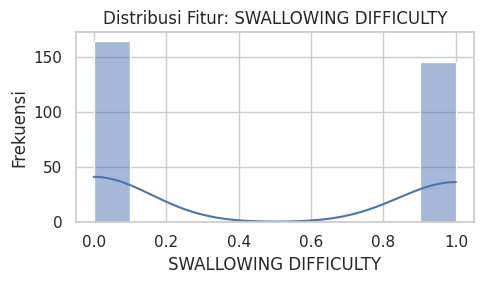

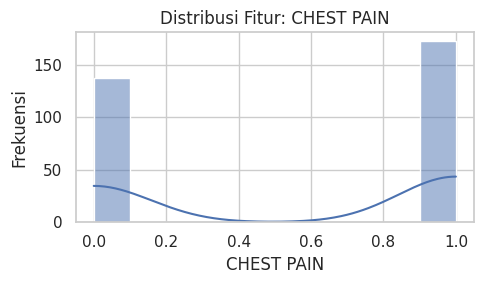

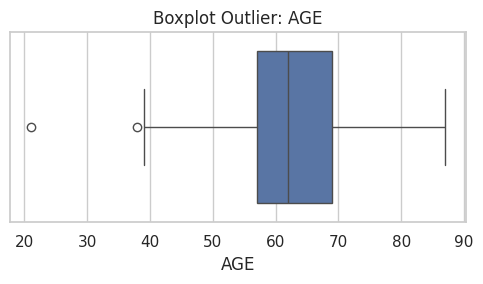

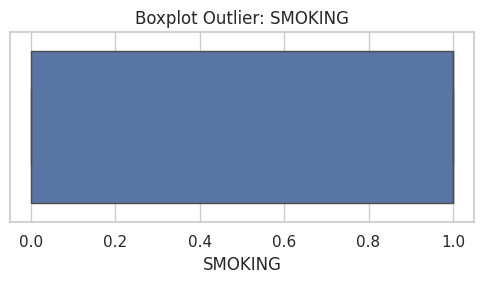

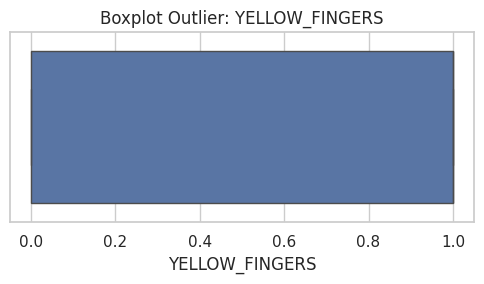

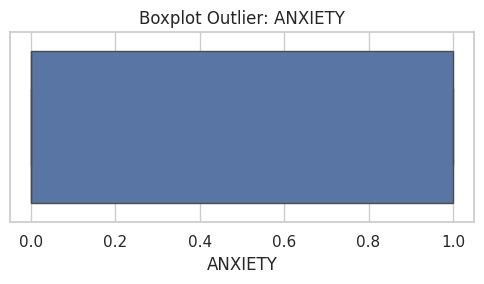

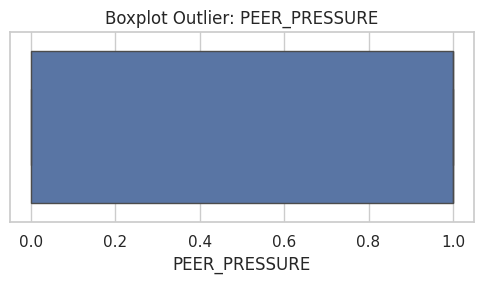

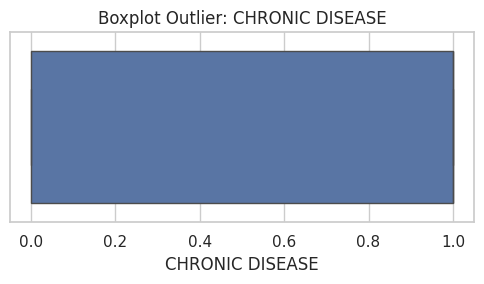

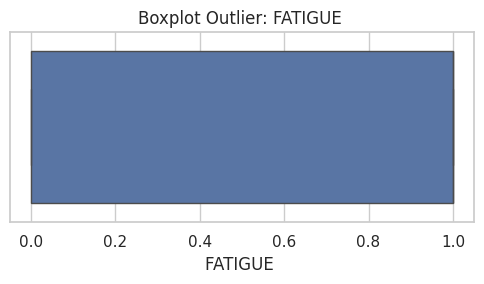

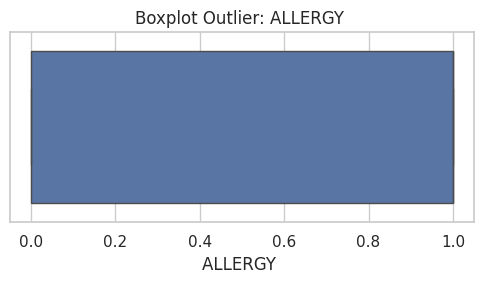

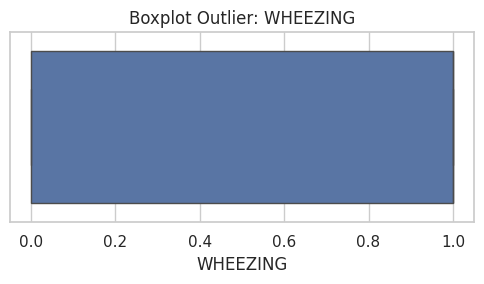

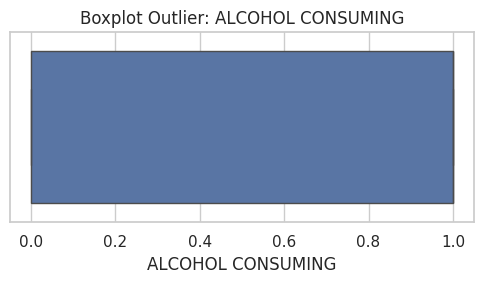

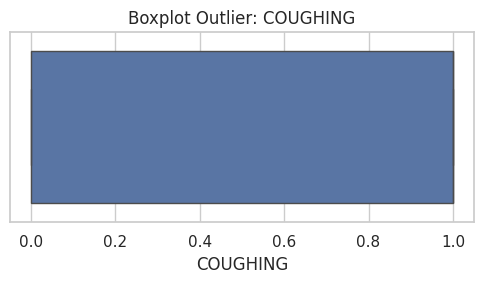

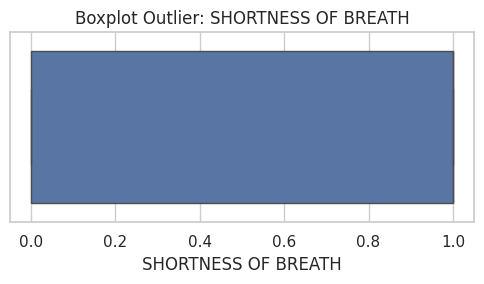

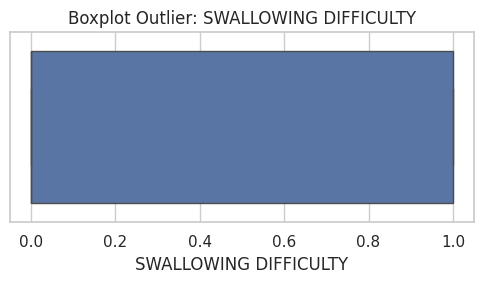

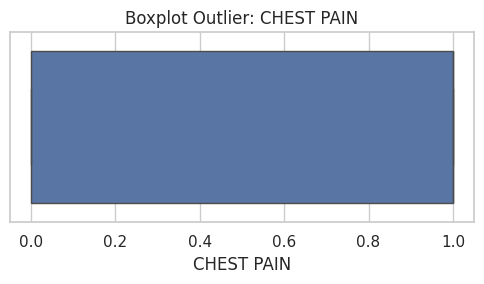

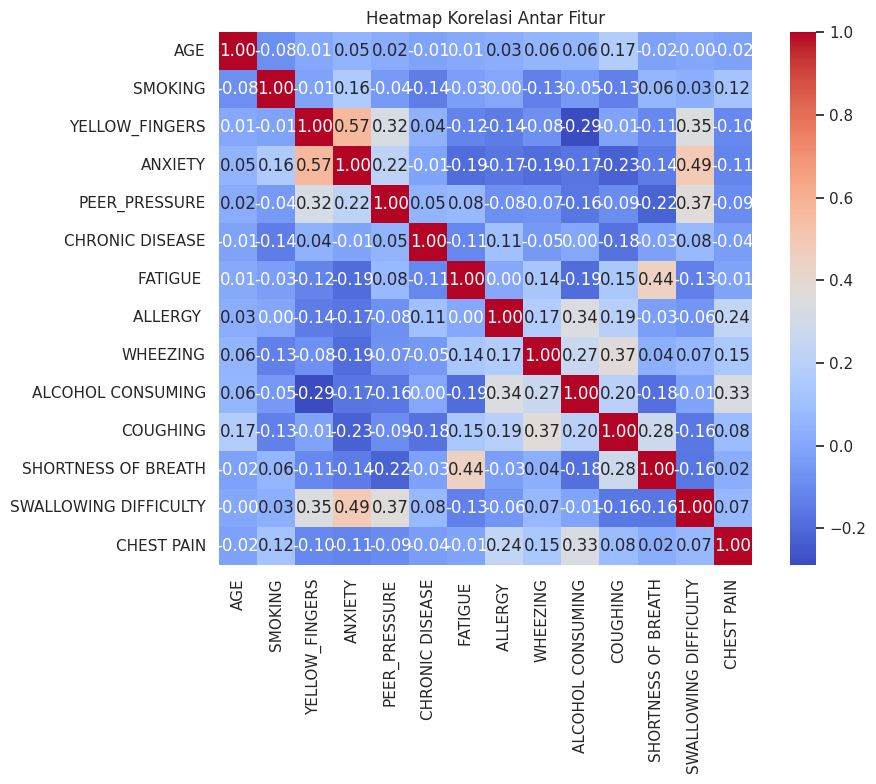

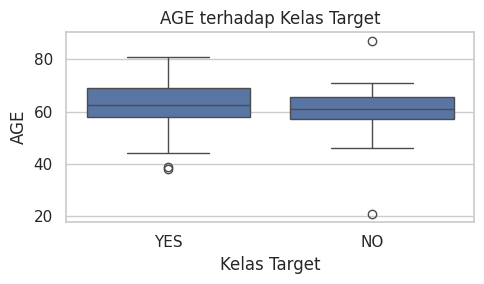

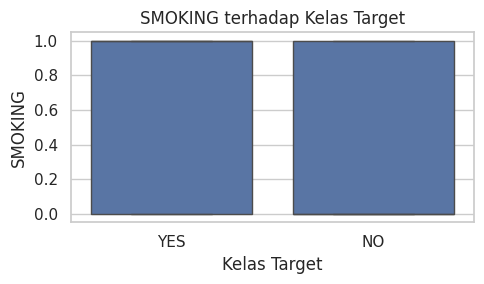

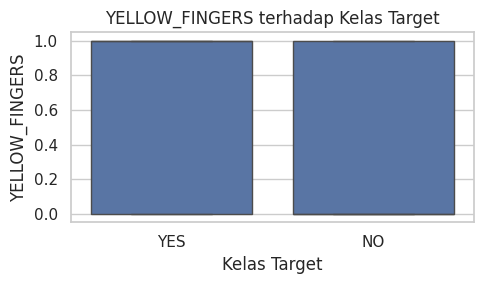

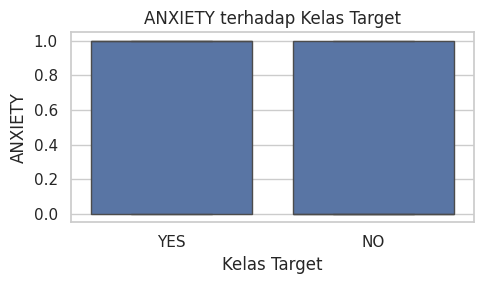

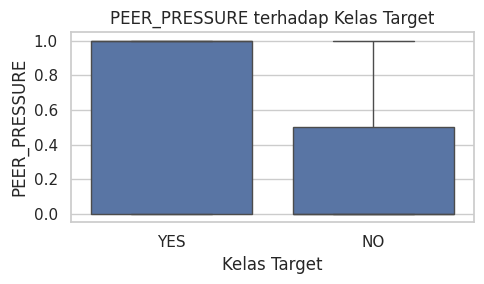

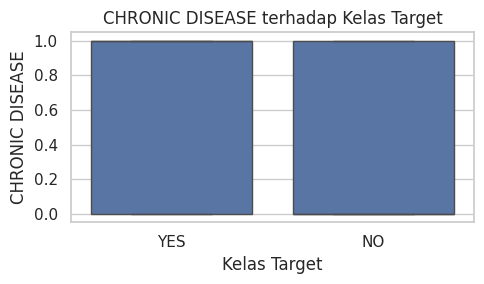

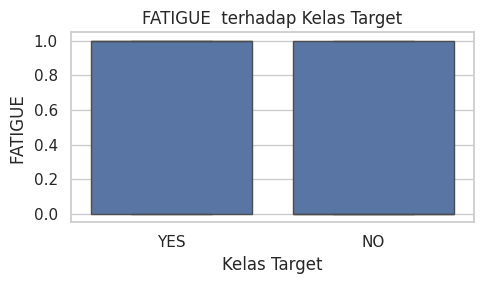

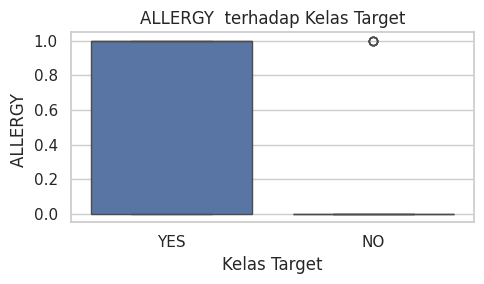

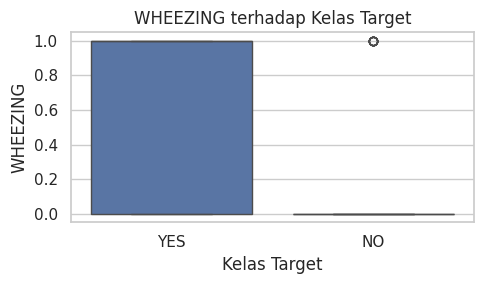

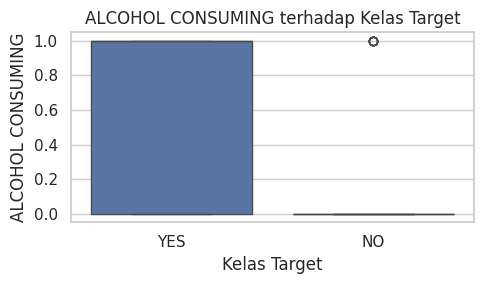

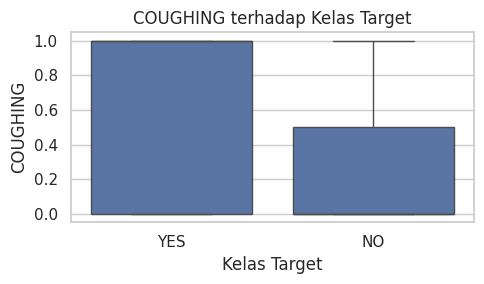

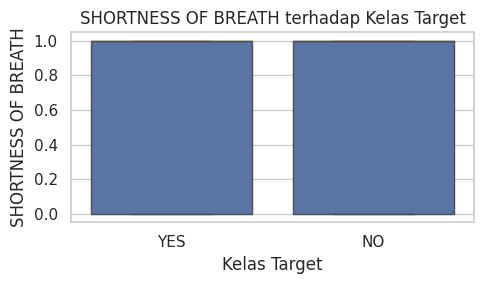

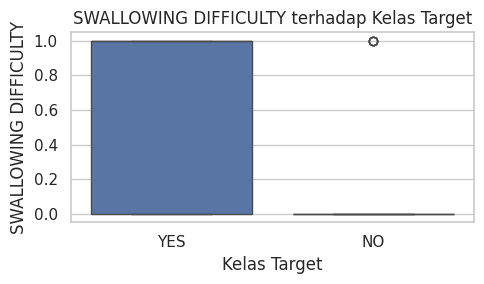

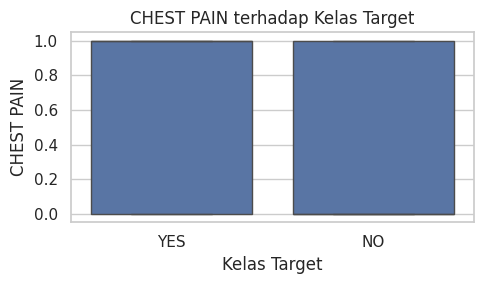


=== RINGKASAN EDA ===
- Dataset telah dianalisis secara statistik dan visual
- Distribusi kelas target menunjukkan ketidakseimbangan
- Tidak ditemukan missing value maupun data duplikat
- Potensi outlier dan korelasi antar fitur telah dianalisis
- Hubungan antara fitur dan target telah diamati


In [ ]:
# =========================================================
# PENENTUAN KOLOM TARGET
# =========================================================
# Dataset: Survey Lung Cancer
target_column = "LUNG_CANCER"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Kolom target: {target_column}")
print("Distribusi kelas target:")
print(y.value_counts())


# =========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Tahap: Data Understanding (CRISP-DM)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")


# =========================================================
# 1. INFORMASI UMUM DATASET
# =========================================================
print("\n[1] Informasi Umum Dataset")
print("Jumlah baris dan kolom:", df.shape)
print("Nama kolom:")
print(df.columns.tolist())


# =========================================================
# 2. TIPE DATA SETIAP KOLOM
# =========================================================
print("\n[2] Tipe Data Setiap Kolom")
print(df.dtypes)


# =========================================================
# 3. STATISTIK DESKRIPTIF
# =========================================================
print("\n[3] Statistik Deskriptif Fitur Numerik")
print(df.describe())


# =========================================================
# 4. ANALISIS MISSING VALUE
# =========================================================
print("\n[4] Analisis Missing Value")

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

print(missing_df)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Percentage (%)"]
)
plt.xticks(rotation=90)
plt.title("Persentase Missing Value per Kolom")
plt.tight_layout()
plt.show()


# =========================================================
# 5. ANALISIS DISTRIBUSI KELAS TARGET
# =========================================================
print("\n[5] Distribusi Kelas Target (Jumlah)")
print(y.value_counts())

print("\nDistribusi Kelas Target (Persentase)")
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

# =========================================================
# 6. CEK DAN TAMPILKAN DATA DUPLIKAT
# Tahap: Data Understanding (CRISP-DM)
# =========================================================

import pandas as pd

# 1. Hitung jumlah duplikat (berdasarkan seluruh kolom)
duplicate_mask = df.duplicated()
jumlah_duplikat = duplicate_mask.sum()

print("Jumlah data duplikat:", jumlah_duplikat)


# 2. Tampilkan baris yang terdeteksi sebagai duplikat
if jumlah_duplikat > 0:
    print("\n[BARIS DUPLIKAT SAJA]")
    display(df[duplicate_mask])
else:
    print("\nTidak ditemukan data duplikat.")


# 3. Tampilkan duplikat BESERTA pasangan aslinya (PALING JELAS)
duplicate_all = df[df.duplicated(keep=False)]

if not duplicate_all.empty:
    print("\n[DATA DUPLIKAT + PASANGAN ASLINYA]")
    display(
        duplicate_all
        .sort_values(by=df.columns.tolist())
        .reset_index()
        .rename(columns={"index": "Row_Index"})
    )


# 4. (OPSIONAL) Cek duplikat berdasarkan kolom tertentu saja
# Contoh: AGE dan GENDER
subset_cols = ["AGE", "GENDER"]

duplicate_subset = df[df.duplicated(subset=subset_cols, keep=False)]

if not duplicate_subset.empty:
    print(f"\n[DUPLIKAT BERDASARKAN KOLOM {subset_cols}]")
    display(
        duplicate_subset
        .sort_values(by=subset_cols)
        .reset_index()
        .rename(columns={"index": "Row_Index"})
    )

# =========================================================
# 7. ANALISIS FITUR KATEGORIKAL TERHADAP TARGET
# =========================================================
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=y, data=df)
    plt.title(f"Distribusi {col} terhadap Target")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()




# =========================================================
# 8. DISTRIBUSI FITUR NUMERIK
# =========================================================
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop(target_column, errors="ignore")

for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi Fitur: {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


# =========================================================
# 9. DETEKSI OUTLIER (BOXPLOT)
# =========================================================
for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot Outlier: {col}")
    plt.tight_layout()
    plt.show()


# =========================================================
# 10. KORELASI ANTAR FITUR NUMERIK
# =========================================================
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.tight_layout()
plt.show()


# =========================================================
# 11. HUBUNGAN FITUR NUMERIK TERHADAP TARGET
# =========================================================
for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=y, y=df[col])
    plt.title(f"{col} terhadap Kelas Target")
    plt.xlabel("Kelas Target")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# =========================================================
# 12. RINGKASAN TEMUAN EDA
# =========================================================
print("\n=== RINGKASAN EDA ===")
print("- Dataset telah dianalisis secara statistik dan visual")
print("- Distribusi kelas target menunjukkan ketidakseimbangan")
print("- Tidak ditemukan missing value maupun data duplikat")
print("- Potensi outlier dan korelasi antar fitur telah dianalisis")
print("- Hubungan antara fitur dan target telah diamati")


In [ ]:
# =========================================================
# DATA PREPARATION (CRISP-DM)
# Dengan SMOTETomek sebelum split
# =========================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek


# =========================================================
# 0. HAPUS DATA DUPLIKAT
# =========================================================
print("Jumlah data sebelum hapus duplikat:", df.shape[0])

df_clean = df.drop_duplicates()

print("Jumlah data setelah hapus duplikat :", df_clean.shape[0])
print("Duplikat dihapus                   :", df.shape[0] - df_clean.shape[0])


# =========================================================
# 1. PISAHKAN FITUR DAN TARGET
# =========================================================
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]


# =========================================================
# 2. ENCODING TARGET
# =========================================================
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("\nDistribusi kelas SEBELUM SMOTETomek:")
print(pd.Series(y).value_counts())


# =========================================================
# 3. IDENTIFIKASI TIPE FITUR
# =========================================================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nFitur numerik     :", list(numeric_features))
print("Fitur kategorikal :", list(categorical_features))


# =========================================================
# 4. PIPELINE PREPROCESSING
# (WAJIB sebelum SMOTETomek)
# =========================================================
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Preprocessing seluruh data
X_prepared = preprocessor.fit_transform(X)


# =========================================================
# 5. SMOTETomek (SEBELUM SPLIT)
# =========================================================
smotetomek = SMOTETomek(random_state=42)

X_balanced, y_balanced = smotetomek.fit_resample(X_prepared, y)

print("\nDistribusi kelas SETELAH SMOTETomek:")
print(pd.Series(y_balanced).value_counts())


# =========================================================
# 6. SPLIT DATA
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("\nDistribusi kelas TRAIN:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi kelas TEST:")
print(pd.Series(y_test).value_counts())


# =========================================================
# 7. INFORMASI AKHIR
# =========================================================
print("\nData preparation selesai.")
print("Shape data latih :", X_train.shape)
print("Shape data uji   :", X_test.shape)


Jumlah data sebelum hapus duplikat: 309
Jumlah data setelah hapus duplikat : 276
Duplikat dihapus                   : 33

Distribusi kelas SEBELUM SMOTETomek:
1    238
0     38
Name: count, dtype: int64

Fitur numerik     : ['AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']
Fitur kategorikal : ['GENDER']

Distribusi kelas SETELAH SMOTETomek:
1    235
0    235
Name: count, dtype: int64

Distribusi kelas TRAIN:
1    188
0    188
Name: count, dtype: int64

Distribusi kelas TEST:
0    47
1    47
Name: count, dtype: int64

Data preparation selesai.
Shape data latih : (376, 16)
Shape data uji   : (94, 16)


In [ ]:
# =========================================================
# MODELING
# =========================================================

from sklearn.neural_network import MLPClassifier


# =========================================================
# 1. MODELING - BASELINE (ADOPSI JURNAL)
# =========================================================
# Arsitektur sesuai jurnal:
# - 1 hidden layer
# - 50 neuron
# - aktivasi tanh
# - optimizer Adam
# - L2 regularization (alpha = 0.0001)
# - tanpa early stopping
# - tanpa dropout

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

# Latih model baseline
mlp_baseline.fit(X_train_prepared, y_train)


# =========================================================
# 2. MODELING - IMPROVEMENT (EKSPERIMEN)
# =========================================================
# Pengembangan model (tetap dalam tahap Modeling):
# - tambah hidden layer
# - ubah nilai L2
# Preprocessing TIDAK DIUBAH

mlp_improvement = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=1000,
    random_state=42
)

# Latih model improvement
mlp_improvement.fit(X_train_prepared, y_train)

MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(50, 50),
              max_iter=1000, random_state=42)

In [ ]:
# =========================================================
# EVALUATION
# =========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PREDIKSI MODEL
# =========================================================
y_pred_baseline = mlp_baseline.predict(X_test_prepared)
y_pred_improvement = mlp_improvement.predict(X_test_prepared)


# =========================================================
# 2. EVALUASI MODEL BASELINE
# =========================================================
print("\n=== EVALUATION : BASELINE MODEL ===")
print("Accuracy :", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_baseline, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_baseline, average="weighted"))

print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))


# Confusion Matrix Baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================================================
# 3. EVALUASI MODEL IMPROVEMENT
# =========================================================
print("\n=== EVALUATION : IMPROVEMENT MODEL ===")
print("Accuracy :", accuracy_score(y_test, y_pred_improvement))
print("Precision:", precision_score(y_test, y_pred_improvement, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_improvement, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_improvement, average="weighted"))

print("\nClassification Report (Improvement):")
print(classification_report(y_test, y_pred_improvement))


# Confusion Matrix Improvement
cm_improvement = confusion_matrix(y_test, y_pred_improvement)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_improvement, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Improvement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================================================
# 4. PERBANDINGAN HASIL MODEL
# =========================================================
comparison = pd.DataFrame({
    "Model": ["Baseline", "Improvement"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_improvement)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, average="weighted"),
        precision_score(y_test, y_pred_improvement, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, average="weighted"),
        recall_score(y_test, y_pred_improvement, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline, average="weighted"),
        f1_score(y_test, y_pred_improvement, average="weighted")
    ]
})

print("\n=== PERBANDINGAN PERFORMA MODEL ===")
print(comparison)
